# Проект: семантический поиск товаров по текстовому запросу

**Ваша роль.** Вы специалист по Data Science. Компания развивает онлайн-каталог товаров, и сейчас руководству кажется, что классический поиск по ключевым словам плохо справляется с реальными запросами. Пользователи пишут названия с ошибками, кириллицей, используют просторечные слова, ищут товары по назначению, а не по функциональности («удобные кроссовки для бега» вместо «мужские спортивные кроссовки с амортизацией»). Команда хочет проверить, поможет ли векторный поиск улучшить качество поисковой системы.

**Задача.** Вам нужно построить MVP системы семантического поиска, сравнить его с лексической baseline-моделью на подготовленной разметке и дать бизнесу обоснованную рекомендацию о том, где новое решение помогает, где ошибается и стоит ли его вообще внедрять.

## Данные

| Файл | Что это | Когда нужен |
|---|---|---|
| wb_products_raw_sample.parquet | Исходный каталог, ~200 тысяч строк, все категории. <br> Вам нужно самостоятельно отобрать рабочее подмножество этих данных | Недели 1–2 |
| wb_products_dedup.parquet | Пул асессоров: множество товаров, по которому делалась разметка | Неделя 2, раздел 4 |
| queries_synthetic_train.parquet | Разметка релевантности, train | Недели 2–3 |
| queries_synthetic_test.parquet | Разметка релевантности, test | **один прогон** в конце недели 3 |

Файлы с разметкой содержат четыре столбца: `query_id`, `query_text`, `item_id`, `relevance`. Шкала в `relevance` от `0` до `3`, где `0` — товар нерелевантен, а `3` — максимально релевантен. Связь с каталогом: `item_id` ↔ `imt_id`.

In [1]:
# Импорты

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from dotenv import load_dotenv
import os

import pyarrow
import s3fs

In [2]:
# Креды и адреса

load_dotenv()

S3_ACC_KEY = os.getenv('S3_ACCESS_KEY_ID')
S3_SECRET_KEY = os.getenv('S3_SECRET_KEY')
S3_BUCKET = os.getenv('S3_BUCKET')

ENDPOINT = 'https://storage.yandexcloud.net'

# Необходимые файлы

RAW_PRODUCTS_PATH = "wb_products_raw_sample.parquet"
ASSESSED_POOL_PATH = "wb_products_dedup.parquet"
TRAIN_QUERIES_PATH = "queries_synthetic_train.parquet"
TEST_QUERIES_PATH = "queries_synthetic_test.parquet"

if not all([S3_ACC_KEY, S3_SECRET_KEY, S3_BUCKET]):
    raise ValueError(
        "Не найдены S3_ACCESS_KEY_ID, S3_SECRET_KEY или S3_BUCKET в .env"
    )

---

## Неделя 1 — знакомство с данными и EDA

**Цель** — понять, с какими данными работаете, чтобы принять обоснованные решения:

- выбрать категории, с которыми будете работать;
- определить, как будете очищать описания от всего лишнего;
- решить, из каких полей собирать текст товара.

**Главный критерий успеха:** любое ваше решение по данным вы можете подкрепить ссылкой на конкретные результаты анализа.

### 1. Загрузка данных

Загрузите каталог и обе разметки. Изучите их структуру: проанализируйте колонки и типы данных в них, определите, что описывает одна строка.

**Подсказка.** `imt_id` — карточка товара, `nm_id` — конкретный артикул этого товара, то есть его разновидность, отличающаяся цветом, размером или чем-то ещё. Определите, что из этого должен возвращать поиск, — от этого зависит, на каком уровне вы будете строить индекс.

In [3]:
fs = s3fs.S3FileSystem(
    key=S3_ACC_KEY,
    secret=S3_SECRET_KEY,
    endpoint_url=ENDPOINT
)

df_raw = pd.read_parquet(
    's3://{}/{}'.format(S3_BUCKET, RAW_PRODUCTS_PATH),
    filesystem=fs,
    engine='pyarrow'
    )
queries_train = pd.read_parquet(
    's3://{}/{}'.format(S3_BUCKET, TRAIN_QUERIES_PATH),
    filesystem=fs,
    engine='pyarrow'
    )
queries_test = pd.read_parquet(
    's3://{}/{}'.format(S3_BUCKET, TEST_QUERIES_PATH),
    filesystem=fs,
    engine='pyarrow'
    )

# Ваш код: размеры, колонки, типы, первые строки

#### Исходный каталог товаров (wb_products_raw_sample)

In [4]:
def df_info(df, name):
    print(f'Размеры датасета {name}:', df.shape)
    print()

    df.info()
    print()

    print('Статистики:')
    display(df.describe(include='all'))
    print()

    print('Несколько первых строк:')
    display(df.head())

    print('Пропуски:')
    missings = df.isna().sum().to_frame()
    missings.columns = ['Кол-во']
    missings['Процент'] = (missings['Кол-во'] / df.shape[0] * 100).round(3)
    display(missings)
    print()

    print('Количество полных дубликатов строк:', df.duplicated().sum())

df_info(df_raw, 'Исходный каталог товаров (wb_products_raw_sample)')

Размеры датасета Исходный каталог товаров (wb_products_raw_sample): (200000, 9)

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   imt_id           200000 non-null  int64
 1   nm_id            200000 non-null  int64
 2   imt_name         200000 non-null  str  
 3   subj_name        200000 non-null  str  
 4   subj_root_name   200000 non-null  str  
 5   nm_colors_names  200000 non-null  str  
 6   vendor_code      200000 non-null  str  
 7   description      200000 non-null  str  
 8   brand_name       200000 non-null  str  
dtypes: int64(2), str(7)
memory usage: 169.5 MB

Статистики:


,imt_id,nm_id,imt_name,subj_name,subj_root_name,nm_colors_names,vendor_code,description,brand_name
count,2.000000e+05,2.000000e+05,200000,200000,200000,200000,200000,200000,200000
unique,NaN,NaN,104046,3234,65,9647,191340,88801,13319
top,NaN,NaN,Платье,Платья,Одежда,,,,Airline
freq,NaN,NaN,4703,6998,43316,34226,6646,57500,2691
mean,9.313147e+06,1.209294e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,5.428525e+06,3.880015e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000e+05,1.074950e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.002833e+07,1.338821e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.007894e+07,1.345970e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.013513e+07,1.353642e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Несколько первых строк:


,imt_id,nm_id,imt_name,subj_name,subj_root_name,nm_colors_names,vendor_code,description,brand_name
0,100000,118982,Сумка,Сумки,Аксессуары,бежевый,82992/beige,,Pola
1,1000000,1206857,Шапка,Шапки,Головные уборы,белый,Лаки/белый,,Ваша Шляпка
2,1000000,1206860,Шапка,Шапки,Головные уборы,черный,Лаки/черный,,Ваша Шляпка
3,10000000,13349975,Очки TRUESPIN Fold,Солнцезащитные очки,Аксессуары,черный,20S.Y.T.35.00.564/Black/Black,,True Spin
4,10000001,13349981,Очки TRUESPIN Candor,Солнцезащитные очки,Аксессуары,черный,20S.Y.T.35.00.567/Black,,True Spin


Пропуски:


,Кол-во,Процент
imt_id,0,0.0
nm_id,0,0.0
imt_name,0,0.0
subj_name,0,0.0
subj_root_name,0,0.0
nm_colors_names,0,0.0
vendor_code,0,0.0
description,0,0.0
brand_name,0,0.0



Количество полных дубликатов строк: 0


Всего в датасете `wb_products_raw_sample` 200 000 строк и 9 полей. Все значения строковые за исключением полей с id товара и артикула.

В датасете не обнаружено ни явных пропусков (NaN), ни полных дубликатов строк. Однако уже сейчас видно, что в полях `nm_colors_names`, `vendor_code` и `description` **присутствует много пустых строк**. Подробнее разберем этот вопрос на этапе EDA.

#### Тренировочная выборка (queries_synthetic_train)

In [5]:
df_info(queries_train, 'Тренировочная выборка (queries_synthetic_train)')

Размеры датасета Тренировочная выборка (queries_synthetic_train): (11453, 4)

<class 'pandas.DataFrame'>
RangeIndex: 11453 entries, 0 to 11452
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   query_id    11453 non-null  str  
 1   query_text  11453 non-null  str  
 2   item_id     11453 non-null  int64
 3   relevance   11453 non-null  int64
dtypes: int64(2), str(2)
memory usage: 854.8 KB

Статистики:


,query_id,query_text,item_id,relevance
count,11453,11453,1.145300e+04,11453.000000
unique,700,700,NaN,NaN
top,SYN_000366,хлопковые футболки,NaN,NaN
freq,31,31,NaN,NaN
mean,NaN,NaN,8.814082e+06,1.218371
std,NaN,NaN,3.457068e+06,0.541248
min,NaN,NaN,1.000370e+05,1.000000
25%,NaN,NaN,1.001999e+07,1.000000
50%,NaN,NaN,1.007633e+07,1.000000
75%,NaN,NaN,1.013258e+07,1.000000



Несколько первых строк:


,query_id,query_text,item_id,relevance
0,SYN_000001,жилеты на пуговицах,100211,3
1,SYN_000001,жилеты на пуговицах,100433,1
2,SYN_000001,жилеты на пуговицах,1000988,1
3,SYN_000001,жилеты на пуговицах,1016032,1
4,SYN_000001,жилеты на пуговицах,10001023,1


Пропуски:


,Кол-во,Процент
query_id,0,0.0
query_text,0,0.0
item_id,0,0.0
relevance,0,0.0



Количество полных дубликатов строк: 0


Всего в датасете `queries_synthetic_train` 11 453 строки и 4 поля. Текст и id запроса представлены текстовыми полями, а id айтема и оценка - числовыми.

Уникальных запросов в датасете всего 700. Видимо, один и тот же запрс оценивался для нескольких товаров.

Явных пропусков и полных дубликатов в датасете не найдено.

#### Тестовая выборка (queries_synthetic_test)

In [6]:
df_info(queries_test, 'Тестовая выборка (queries_synthetic_test)')

Размеры датасета Тестовая выборка (queries_synthetic_test): (4866, 4)

<class 'pandas.DataFrame'>
RangeIndex: 4866 entries, 0 to 4865
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   query_id    4866 non-null   str  
 1   query_text  4866 non-null   str  
 2   item_id     4866 non-null   int64
 3   relevance   4866 non-null   int64
dtypes: int64(2), str(2)
memory usage: 363.5 KB

Статистики:


,query_id,query_text,item_id,relevance
count,4866,4866,4.866000e+03,4866.000000
unique,300,300,NaN,NaN
top,SYN_000424,свободные платья,NaN,NaN
freq,31,31,NaN,NaN
mean,NaN,NaN,8.857696e+06,1.201397
std,NaN,NaN,3.168832e+06,0.533104
min,NaN,NaN,1.000370e+05,1.000000
25%,NaN,NaN,1.002133e+07,1.000000
50%,NaN,NaN,1.007391e+07,1.000000
75%,NaN,NaN,1.012887e+07,1.000000



Несколько первых строк:


,query_id,query_text,item_id,relevance
0,SYN_000003,кардиганы на пуговицах,1000028,1
1,SYN_000003,кардиганы на пуговицах,1000628,3
2,SYN_000003,кардиганы на пуговицах,1008849,2
3,SYN_000003,кардиганы на пуговицах,10002779,1
4,SYN_000003,кардиганы на пуговицах,10007028,2


Пропуски:


,Кол-во,Процент
query_id,0,0.0
query_text,0,0.0
item_id,0,0.0
relevance,0,0.0



Количество полных дубликатов строк: 0


Всего в датасете `queries_synthetic_test` 4 865 строки и 4 поля. Уникальных запросов всего 300.

В остальном (структура, пропуски, дубликаты) тестовый датасет аналогичен обучающему.

**Проверьте связность данных:** все ли `item_id` из разметки есть в каталоге, нет ли пересечения `query_id` между `train` и `test`.

#### Проверка связности данных

Проверим нет ли пересечения `query_id` между обучающей и тестовой выборками.

In [7]:
intersection = set(queries_test['query_id']) & set(queries_train['query_id'])
print('Количество пересекающихся `query_id` в тестовой и обучающей выборках:', len(intersection))
assert len(intersection) == 0, f'Утечка данных! Количество пересечений: {len(intersection)}'

Количество пересекающихся `query_id` в тестовой и обучающей выборках: 0


Пересечений `query_id` между двумя выборками нет - разделение верное.

Проверим все ли `item_id` из разметки есть в каталоге.

In [8]:
catalog_id_set = set(df_raw['imt_id'])

for df, name in [(queries_train, 'train'), (queries_test, 'test'),]:
    df_id_set = set(df['item_id'])
    intersec = catalog_id_set & df_id_set

    print(f'Количество уникальных `item_id` в {name} выборке:', len(df_id_set))
    print('Из них присутствуют в каталоге:', len(intersec))
    print('Разница:', len(df_id_set) - len(intersec))
    print('-' * 10)


Количество уникальных `item_id` в train выборке: 2285
Из них присутствуют в каталоге: 2285
Разница: 0
----------
Количество уникальных `item_id` в test выборке: 1672
Из них присутствуют в каталоге: 1672
Разница: 0
----------


Все айтемы из обучающей и тестовой выборок имеются в каталоге.

### 2. EDA

#### Общий обзор данных и оценка их объёма

Посчитаем количество строк, число уникальных imt_id и nm_id, проверим данные на наличие дубликатов.

In [11]:
print('Количество строк в каталоге:', df_raw.shape[0])
print('Количество уникальных идентификаторов карточек `imt_id`:', df_raw['imt_id'].nunique())
print('Количество уникальных идентификаторов артикулов `nm_id`:', df_raw['nm_id'].nunique())
print('Количество дубликатов пар `imt_id`, `nm_id`:', df_raw.duplicated(subset=['imt_id', 'nm_id']).sum())

Количество строк в каталоге: 200000
Количество уникальных идентификаторов карточек `imt_id`: 174427
Количество уникальных идентификаторов артикулов `nm_id`: 199957
Количество дубликатов пар `imt_id`, `nm_id`: 43


Имеем 43 дубля пар `imt_id`, `nm_id`. Уникальных `nm_id` 199 957 штуки, значит ни один из дублирующихся `nm_id` не принадлежит разным `imt_id`.

Такие дубликаты удалять пока не будем так как нам все равно придется агрегировать данные по `imt_id`.

#### Полнота полей

Оценим долю пропусков в текстовых полях.

In [30]:
missings = df_raw.select_dtypes(include='str').eq('').sum().to_frame()
missings.columns = ['Count']
missings['Perc'] = (missings['Count'] / df_raw.shape[0] * 100).round(2)

print('Количество пропусков в текстовых полях:')
display(missings)

print('Количество строк с одновременно отсутствующими названием и описанием:', end=' ')
print(df_raw[['imt_name', 'description']].eq('').all(axis=1).sum())

Количество пропусков в текстовых полях:


,Count,Perc
imt_name,708,0.35
subj_name,8,0.00
subj_root_name,8,0.00
nm_colors_names,34226,17.11
vendor_code,6646,3.32
description,57500,28.75
brand_name,201,0.10


Количество строк с одновременно отсутствующими названием и описанием: 163


**Товаров без названия оказалось 708 штук (около 0.35%)** из которых 163 не имеют описания - то есть семантический поиск для них едва ли возможен, но удалять тоже не вариант так как они могут пригодиться, например для fallback по категории.

**Без описания почти 30% товаров.** Удалять такое большое количество товаров из каталога было бы неправильным. Можно оставить добавив метку отсутствия описания.

#### Распределение по категориям

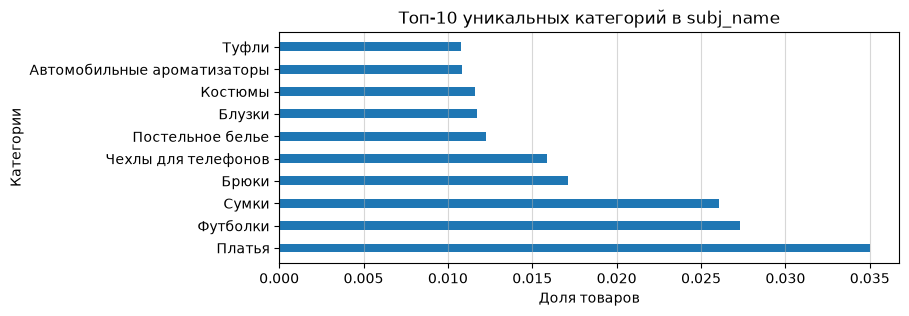

Всего уникальных значений в поле `subj_name`: 3234
Доля товаров, которая приходится на топ-10 категорий: 12.14%


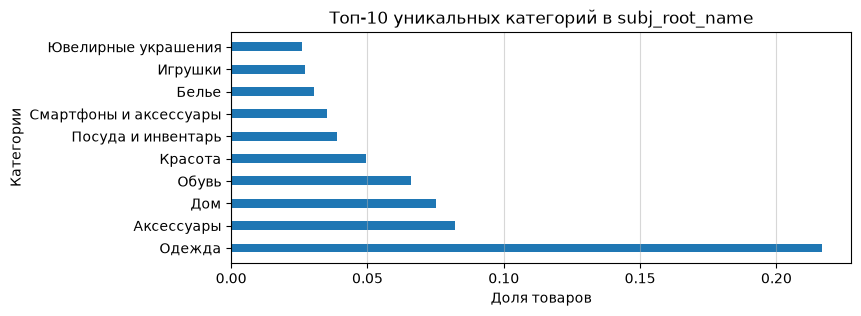

Всего уникальных значений в поле `subj_root_name`: 65
Доля товаров, которая приходится на топ-10 категорий: 48.93%


In [59]:
k = 10

for col in ['subj_name', 'subj_root_name']:
    counts = df_raw[col].value_counts(normalize=True)

    plt.figure(figsize=(8, 3))
    plt.barh(counts.head(k).index, counts.head(k), height=.4)

    plt.xlabel('Доля товаров')
    plt.ylabel('Категории')
    plt.title(f'Топ-{k} уникальных категорий в {col}')
    plt.grid(axis='x', alpha=.5)
    plt.show()

    print(f'Всего уникальных значений в поле `{col}`:', len(counts))
    print(f'Доля товаров, которая приходится на топ-{k} категорий: ',
          round(counts.head().sum() * 100, 2), '%', sep='')

Проверим какие категории есть в тренирововчной выборке.

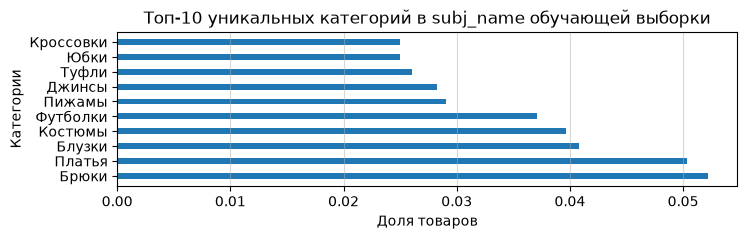

Всего уникальных значений в поле `subj_name`: 89
Доля товаров, которая приходится на топ-10 категорий: 22.01%


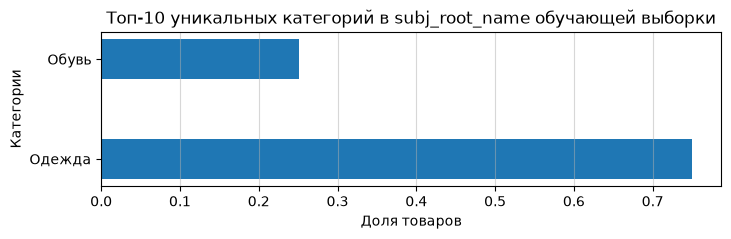

Всего уникальных значений в поле `subj_root_name`: 2
Доля товаров, которая приходится на топ-10 категорий: 100.0%


In [62]:
ids_in_train = queries_train['item_id']

for col in ['subj_name', 'subj_root_name']:
    counts = df_raw[df_raw['imt_id'].isin(ids_in_train)][col].value_counts(normalize=True)

    plt.figure(figsize=(8, 2))
    plt.barh(counts.head(k).index, counts.head(k), height=.4)

    plt.xlabel('Доля товаров')
    plt.ylabel('Категории')
    plt.title(f'Топ-{k} уникальных категорий в {col} обучающей выборки')
    plt.grid(axis='x', alpha=.5)
    plt.show()

    print(f'Всего уникальных значений в поле `{col}`:', len(counts))
    print(f'Доля товаров, которая приходится на топ-{k} категорий: ',
          round(counts.head().sum() * 100, 2), '%', sep='')

Топ категорий из каталога:
- Одежда
- Аксессуары
- Дом
- Обувь
- Красота

Всего уникальных категорий в каталоге 65.  
На топ-10 категорий из каталога 48.93% - то есть почти половина.
Однако, в обучающей выборке присутствуют только категории Одежда и Обувь. Поэтому обучение будет ограничено этит двумя категориями.

#### Длина текстовых полей

---

## Неделя 2 — базовый пайплайн и оценка качества

**Цель:** оперевшись на результаты EDA, создать работающий поиск и получить первые метрики качества.

Прежде чем реализовывать семантический поиск, основанный на эмбеддингах, нужно проверить, как справляется более простая модель, опирающаяся на TF-IDF. Простая модель нужна как baseline, без этой точки отсчёта результат невозможно интерпретировать.


### 1. Подготовка данных


Реализуйте решения недели 1:

1. Отфильтруйте выбранные категории.
2. Дедуплицируйте строки по `imt_id`. Сформулируйте правило, по которому будете определять, какую строку оставить. К примеру, можете оставить строку с самым информативным описанием. Ответ обоснуйте.
3. Отбросьте карточки, у которых пусты одновременно и `imt_name`, и `description`.
4. Напишите функцию очистки текста.
5. Соберите единый текст карточек в отдельной колонке `product_text`.

In [ ]:
# Ваш код: фильтрация, дедупликация, отсев пустых, очистка, сборка product_text

### Каталог для поиска и оценки

1. Посчитайте метрику при поиске по всему отфильтрованному каталогу. Например, вычислите NDCG@10 лексическим поиском на 100 запросах.
2. Выведите топ-10 для одного запроса и отметьте, какие товары есть в разметке, а каких нет. Выясните, в чём проблема.
3. Ограничьте каталог оценки пулом асессоров: возьмите из `wb_products_dedup.parquet` только список `imt_id` и оставьте в своём подготовленном каталоге пересечение с ним. Тексты и все признаки — ваши, из шага 1.
4. Пересчитайте метрику и сравните результаты.
5. Посмотрите на распределение `relevance` и число оценённых товаров на запрос. Проверьте, у всех ли запросов есть товары с `relevance` ≥ 2.

### 2. Модели поиска

Реализуйте два поисковых движка с одинаковым интерфейсом. Это позволит прогнать оба через одну функцию оценки:

In [ ]:
def search_xxx(query: str, top_k: int = 10) -> pd.DataFrame:
    """Возвращает top_k товаров с колонками imt_id, imt_name, subj_name, score."""


Реализуйте лексический baseline на TF-IDF:

In [ ]:
# Ваш код: TF-IDF-индекс и search_lexical

Реализуйте семантический поиск:

In [ ]:
# Ваш код: эмбеддинги и search_semantic


Прогоните 3–5 запросов вручную и сравните выдачу обоих подходов. Это самый простой способ поймать грубые ошибки до подсчёта метрик.

In [ ]:
# Ваш код

### 3. Оценка качества решений

Реализуйте метрики Precision@K, Recall@K, MRR, NDCG@K, HitRate@K.

Три ключевые особенности, которые надо учесть при расчёте:

1. Порог бинаризации. Precision@K, Recall@K, MRR, HitRate@K бинарны, а шкала `relevance` — от `0` до `3`. С какой оценки товар считается релевантным? Вынесите порог в параметр, а не константу внутри функции.
2. NDCG считайте по полной шкале 0–3 (`gain = 2^rel - 1`), а не по бинаризованной, иначе теряется смысл градуированной разметки.
3. Неразмеченные товары в выдаче трактуйте как нерелевантные (`relevance_map.get(item_id, 0)`).

Выводы запишите в Markdown-ячейке и рабочем файле Markdown.

In [ ]:
RELEVANCE_THRESHOLD = 2   # Ваше решение, его нужно обосновать

# Ваш код для работы с метриками


---

## Неделя 3 — эксперименты, дообучение и MLflow

**Цель:** проверить гипотезы о том, как можно улучшить систему поиска, зафиксировать эксперименты, дать рекомендации бизнесу.

**Главное правило:** «один эксперимент — одна гипотеза — одно изменение». Если поменять сразу модель, шаблон текста и параметры векторизации, прирост будет невозможно объяснить и повторить.

### 1. Эксперименты по улучшению

Проведите минимум три эксперимента. Оформляйте каждый по схеме:

- **Гипотеза** — ваше предположение и его обоснование. Причины «хочу попробовать другую модель» недостаточно, нужны объяснения такого типа: «Модель с большим окном улучшит поиск товаров с длинными описаниями, потому что в EDA я видел, что X% описаний обрезаются по лимиту токенов».
- **Что меняется** — ровно один компонент относительно baseline.
- **Результат** — метрики на тех же данных, с тем же порогом и теми же K.
- **Вывод** — принимаем или отклоняем гипотезу. Что это говорит о данных?

Придумывайте гипотезы, опираясь на ошибки, которые обнаружили на неделе 2. Если выбранная модель путает смежные категории, попробуйте проверить, решит ли проблему добавление данных из `subj_name` в общий текст карточки. Другой пример: если лексический поиск обходит семантический на точных названиях, а семантический выигрывает у лексического, когда дело доходит до неточных формулировок, — это повод попробовать реализовать гибридный поиск.

Направления для разработки гипотез:

- изменить шаблон `product_text`;
- попробовать другую модель эмбеддингов;
- дообучить модели;
- реализовать гибридный поиск с помощью взвешенной суммы скоров или реранкинга семантикой поверх лексического отбора;
- ввести лемматизацию и стоп-слова для TF-IDF;
- изменить параметры векторизации.

In [ ]:
# Эксперимент 1
# Гипотеза:
# Что меняем:


# Ваш код

...

### 2. Финальный тест

Выборка `test` нужна для финальной проверки модели, когда конфигурация окончательно выбрана по результатам валидации. Каждый повторный прогон с подстройкой превращает `test` в ещё одну валидацию и обесценивает финальные показатели.

In [ ]:
RUN_FINAL_TEST_EVAL = False   # Переведите в True, когда конфигурация финальная

# Ваш код


### 3. Трекинг экспериментов в MLflow

Каждая конфигурация — отдельный run с осмысленным именем (`semantic_bge_m3`, а не `run_7`).

Что логировать:
- Все параметры, известные до запуска, — метод, модель, шаблон текста, порог, размер каталога, сид.
- Метрики — все посчитанные значения.
- Артефакты — таблица метрик по запросам, сводная таблица, графики, копия данных, на которых проводилась проверка.

In [ ]:
# Ваш код: подключение к MLflow из .env и логирование прогонов

### 4. Финальные выводы

**4.1. Сводная таблица.** Все подходы на одних данных, с одинаковыми порогом и K. Укажите лучшую конфигурацию и метрики, по которым был сделан вывод.

**4.2. Качественный анализ.** Числа показывают не всю картину. Возьмите запросы, где лучший подход всё ещё ошибается, и опишите характер ошибок.

**4.3. Ограничения оценки.** Перечислите ограничения модели и данных, на которых проводились эксперименты. Например:

- разметка синтетическая и пулированная;
- каталог оценки меньше реального;
- запросы сгенерированы, а не собраны от пользователей.

Этот раздел не ослабляет работу, а усиливает её: специалист, понимающий границы своего решения, вызывает больше доверия.

**4.4. Рекомендация бизнесу.** Скажите заказчику, внедрять ли ему векторный поиск или нет, в каком виде его лучше реализовывать, в каких сценариях он будет помогать, а где может ошибаться.

**4.5. Дальнейшие шаги.** Перечислите возможные действия, которые могли бы улучшить результат:

- использовать реальные логи запросов вместо синтетических;
- перейти на ANN-индекс при росте каталога;
- применить фильтры по атрибутам поверх векторного поиска.

Все возможные шаги обоснуйте.


*Ваши выводы:*
